<a href="https://colab.research.google.com/github/solosolve-ai/solosolve-ai/blob/main/src/notebooks/SFT_Generation_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Installs,Imports, Drive Setup, DB ETL**

In [ ]:
# ==============================================================================
# Cell 1: Clean Setup - Installs, Imports, and Data Loading
# ==============================================================================

# Install required packages
!pip install -q pandas duckdb google-generativeai polars pydantic tqdm

# Core imports
import os
import json
import pandas as pd
import polars as pl
import duckdb
import google.generativeai as genai
from google.colab import drive, userdata
from IPython.display import display

# Mount drive and configure API
drive.mount('/content/drive')
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
genai.configure(api_key=os.environ["GOOGLE_API_KEY"])

# Setup project paths
PROJECT_FOLDER = "/content/sft_data_generation_revised"
CHECKPOINT_DIR = os.path.join(PROJECT_FOLDER, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Load data from CSV into DuckDB
con = duckdb.connect(":memory:")
df_pandas = pd.read_csv('/content/drive/MyDrive/cleaned_amazon_fashion_data.csv',
                       encoding='latin-1', on_bad_lines='skip')

# Clean numeric columns and create table
for col in ['price', 'rating', 'rating_number', 'average_rating']:
    df_pandas[col] = pd.to_numeric(df_pandas[col], errors='coerce')

con.execute("CREATE TABLE reviews AS SELECT * FROM df_pandas WHERE rating <= 2")

# Load complaint data into Polars
df_complaints = (
    con.execute("SELECT text, product_title, price, rating FROM reviews").pl()
    .drop_nulls(subset=["text", "product_title"])
    .with_row_index("original_index")
    .sample(n=5000, shuffle=True, seed=42)
)

print(f"Loaded {len(df_complaints)} complaint records")
display(df_complaints.head(3).to_pandas())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 5000 complaint records


,original_index,text,product_title,price,rating
0,10451,"These have fallen apart in less than 2 months,...",NELEUS Women's 3 Pack Compression Base Layer D...,21.96,2.0
1,19384,So flat like an ass,Jeanewpole1 Womens Down Puffer Short Jacket Qu...,54.99,1.0
2,35367,"The description says the dress has ""some stret...",LILBETTER Women V-Neck Polka Dot Print Spaghet...,35.99,2.0


#**DB Validation Checks**

**Record Duplication**: The composite key {user_id, parent_asin, timestamp} is not unique, indicating the presence of duplicate records. This is a known data characteristic that will be handled via deduplication prior to any event-based analysis.

**User-to-Review Relationship**: A one-to-many relationship between users and reviews was confirmed. user_id is a reliable key for grouping and user-centric analysis.

**Product Identifier Integrity**: The parent_asin identifier is highly reliable, mapping consistently to a single product_title. It is a robust key for all product-level aggregations.

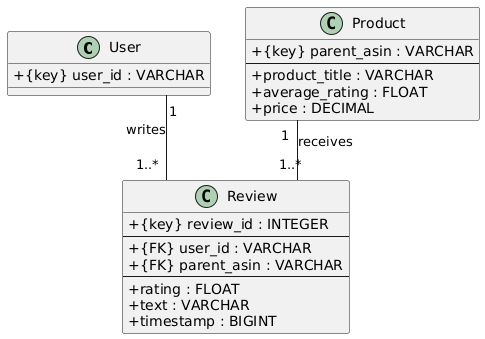

In [ ]:
# Find any combination of user, product, and timestamp that appears more than once.
duplicate_reviews_query = """
SELECT
    user_id,
    parent_asin,
    timestamp,
    COUNT(*) AS occurrence_count
FROM
    reviews
GROUP BY
    user_id,
    parent_asin,
    timestamp
HAVING
    COUNT(*) > 1
ORDER BY
    occurrence_count DESC;
"""

# Execute the query and display the results
print("Finding duplicate reviews based on user, parent_asin, and timestamp:")
duplicate_reviews_df = con.sql(duplicate_reviews_query).df()
display(duplicate_reviews_df)

Finding duplicate reviews based on user, parent_asin, and timestamp:


,user_id,parent_asin,timestamp,occurrence_count
0,None,None,<NA>,47
1,AE22JJNSDFUJU4JXP6NRFBPOSWWA,B0169U8R40,1608149317130,9
2,AEFGFT4DPFCHBI2N3A5ACWU42VRA,B0949Q33GQ,1634925288279,7
3,AH4TYC24BUYJWRGKKAHHHWG6V56Q,B07519VZMF,1652666149298,6
4,AFAS5M56OZXBJI4T6JAZAO64UNTA,B0765PQ6WW,1587348505296,6
...,...,...,...,...
608,AHO6BFMV7SKYZZFGCUXUAZXQLDQQ,B07JWLTCLX,1607800650896,2
609,AESJA6KBFOHDGB7XFRHJ2L5XPYDA,B018P61XRY,1535481049644,2
610,AH43L4K5K3LWUPJIXJU4L2K3OYFA,B0B9S2D5G6,1603183640869,2
611,AG7ZUD4VYFG5JHTD7S3REGVXUL7A,B07FLJXQMQ,1562509189217,2


In [ ]:
# Find users who have written more than one review (who left more than one 1 or 2-star rating)
most_active_reviewers_query = """
SELECT
    user_id,
    COUNT(*) AS number_of_reviews
FROM
    reviews
GROUP BY
    user_id
HAVING
    COUNT(*) > 1
ORDER BY
    number_of_reviews DESC
LIMIT 10; -- Show the top 10 most active reviewers
"""

# Execute the query and display the results
print("Finding users who have written more than one review:")
most_active_reviewers_df = con.sql(most_active_reviewers_query).df()
display(most_active_reviewers_df)

Finding users who have written more than one review:


,user_id,number_of_reviews
0,None,47
1,AE22JJNSDFUJU4JXP6NRFBPOSWWA,9
2,AEFGFT4DPFCHBI2N3A5ACWU42VRA,7
3,AHZU5DYRAH6XS2E32PA3GKZFIMKQ,6
4,AH4TYC24BUYJWRGKKAHHHWG6V56Q,6
5,AELIE2JHGEPX7XCFFNBT3HUL2BMQ,6
6,AFAS5M56OZXBJI4T6JAZAO64UNTA,6
7,AFCHMGM7D3S744JAIEAM54XVLAQQ,5
8,AEBBOCDUD3Q6IMXYM2BRKFHSEGZQ,5
9,AH3WPHVI5GF3RXF5UAENFQWDL2BQ,5


In [ ]:
# Find products (parent_asin) that are associated with more than one product_title
multiple_titles_query = """
SELECT
    parent_asin,
    COUNT(DISTINCT product_title) AS number_of_unique_titles
FROM
    reviews
GROUP BY
    parent_asin
HAVING
    COUNT(DISTINCT product_title) > 1
ORDER BY
    number_of_unique_titles DESC;
"""

# Execute the query and display the results
print("Finding products associated with more than one product_title:")
multiple_titles_df = con.sql(multiple_titles_query).df()
display(multiple_titles_df)

Finding products associated with more than one product_title:


,parent_asin,number_of_unique_titles


In [ ]:
# Display the first few rows of the 'reviews' table
print("Displaying first 5 rows of the 'reviews' table:")
display(con.sql('SELECT * FROM reviews LIMIT 5').df())

# Get the row count from the 'reviews' table
reviews_row_count = con.sql('SELECT COUNT(*) FROM reviews').df().iloc[0, 0]
print(f"\nNumber of rows in 'reviews' table: {reviews_row_count}")

# Get the row count from the 'df' DataFrame (assuming it's still in memory)
if 'df' in locals():
    df_row_count = len(df)
    print(f"Number of rows in 'df' DataFrame: {df_row_count}")
    # Validate row counts
    if reviews_row_count == df_row_count:
        print("Validation successful: Row counts match between 'reviews' table and 'df' DataFrame.")
    else:
        print("Validation warning: Row counts do not match between 'reviews' table and 'df' DataFrame.")
else:
    print("'df' DataFrame not found in memory. Cannot compare row counts.")


# Get the number of unique values in the 'reviews' table for each column
print("\nNumber of unique values in each column of 'reviews' table:")
unique_counts_query = """
    SELECT
        COUNT(DISTINCT rating) AS unique_rating,
        COUNT(DISTINCT text) AS unique_text,
        COUNT(DISTINCT asin) AS unique_asin,
        COUNT(DISTINCT parent_asin) AS unique_parent_asin,
        COUNT(DISTINCT user_id) AS unique_user_id,
        COUNT(DISTINCT timestamp) AS unique_timestamp,
        COUNT(DISTINCT product_title) AS unique_product_title,
        COUNT(DISTINCT average_rating) AS unique_average_rating,
        COUNT(DISTINCT rating_number) AS unique_rating_number,
        COUNT(DISTINCT features) AS unique_features,
        COUNT(DISTINCT price) AS unique_price,
        COUNT(DISTINCT store) AS unique_store,
        COUNT(DISTINCT details) AS unique_details
    FROM reviews;
"""
unique_counts_df = con.sql(unique_counts_query).df()
display(unique_counts_df)

Displaying first 5 rows of the 'reviews' table:


,rating,text,asin,parent_asin,user_id,timestamp,product_title,average_rating,rating_number,features,price,store,details
0,2.0,"I am 5'7"".. usually wear a 14/16 or 0x/1x.. 38...",B095CHR38Z,B095CHR38Z,AFZUK3MTBIBEDQOPAK3OATUOUKLA,1645062075013,Womens Short Sleeve V Neck Shirts Loose Tops B...,3.0,7,"Spandex,Rayon",10.990000,Ladmous,"{""Package Dimensions"": ""10.87 x 6.89 x 1.26 in..."
1,1.0,The photo doesn't show this but you need a col...,B074XF4KG4,B074XF4KG4,AFZUK3MTBIBEDQOPAK3OATUOUKLA,1611092662402,Nike Women's Dri-Fit Training Hoodie (Plus Siz...,2.9,2,Pull On closure,54.990002,Nike,"{""Is Discontinued By Manufacturer"": ""No"", ""Pac..."
2,1.0,Plastic and all squished. No thanks.,B07BC7X9XV,B07BC7X9XV,AH5APOJ6RSZCRQOCQ24R7IUO6YIA,1575022356854,Exquisite Women's Sterling Silver Ring Oval Cu...,3.7,34,None,1.490000,Gyouandme,"{""Is Discontinued By Manufacturer"": ""No"", ""Dat..."
3,1.0,This is where all the cracker Jack's prizes are??,B0795SXS5H,B0795PF8H7,AEIMJ5XEUIE4TKJLGSZYNNKB2WDQ,1535430500993,Clearance Multilayer Irregular Crystal Opals P...,3.8,68,"Alloy | Imported | OCCASION:Suits Wedding,Cock...",0.010000,iLH,{}
4,1.0,It looks like moths already attacked it before...,B0BBSK27WH,B0BBSK27WH,AG535JFIAGQV4CY7TREDVYPDNGKA,1671839604333,Sweaters for Women Plus Size Long Sleeve Fall/...,3.0,3,Hand Wash Only,37.990002,Allaruna,"{""Package Dimensions"": ""10.87 x 6.89 x 2.56 in..."



Number of rows in 'reviews' table: 65590
'df' DataFrame not found in memory. Cannot compare row counts.

Number of unique values in each column of 'reviews' table:


,unique_rating,unique_text,unique_asin,unique_parent_asin,unique_user_id,unique_timestamp,unique_product_title,unique_average_rating,unique_rating_number,unique_features,unique_price,unique_store,unique_details
0,2,63084,28934,17412,64364,64796,17239,40,1138,10635,2977,8544,16212


#**Exploratory Data Analysis: Key Drivers of Fashion Reviews**

This analysis synthesizes findings from the dataset of 1 and 2-star fashion reviews to identify the primary factors leading to customer dissatisfaction.

#Findings
**Top Products Prone to Negative Reviews** :

*  The products receiving the most negative reviews are predominantly functional and athletic apparel (e.g., compression wear, hoodies, joggers) and low-cost accessories (e.g., Casio watch, heated gloves).

* This list highlights items where sizing/fit and performance/durability are critical to customer satisfaction, directly aligning with the common complaints identified in the review text.

**Rating Distribution & Severity** :

1-star reviews outnumber 2-star reviews by nearly 2-to-1. This indicates that product failures are typically perceived as critical, warranting the lowest possible rating.

**Price Point Concentration**:

Negative reviews are overwhelmingly concentrated on products priced under $50. However, a t-test confirmed no significant price difference between items rated 1-star vs. 2-star, suggesting price doesn't dictate the severity of the negative rating.

**Primary Complaint Themes with Word cloud**:

Quality & Durability: cheap, broke, quality, poor.
Sizing & Fit: way (too small/big), tight, small, fits.
Expectation Mismatch: picture, looks, disappointed, expected.

# Conclusion
Customer dissatisfaction in this dataset is not random; it is concentrated at the intersection of low price points and high functional expectations.
The primary driver for negative reviews is a value proposition failure, where budget-friendly activewear, multi-packs, and accessories fail to deliver on fundamental attributes like fit, quality, and durability. The data strongly suggests that sellers could mitigate a significant volume of these complaints by providing more accurate sizing guides, setting realistic quality expectations in product descriptions, and improving quality control for performance-oriented apparel.

--- 1. Visualizing Top 10 Most Reviewed Products ---


/usr/local/lib/python3.12/dist-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.





--- 2. Visualizing Distribution of Ratings ---



--- 3. Visualizing Distribution of Prices (< $200) ---



--- 4. Statistical Test: Price Difference for 1 vs 2-Star Ratings ---
Independent Samples T-test Results:
  T-statistic: -1.2807
  P-value: 0.2003

Interpretation: The difference in the mean price between 1-star and 2-star rated products is not statistically significant (p >= 0.05).

--- 5. Visualizing Complaint Volume Over Time ---



--- 6. Generating Word Cloud from Review Text ---


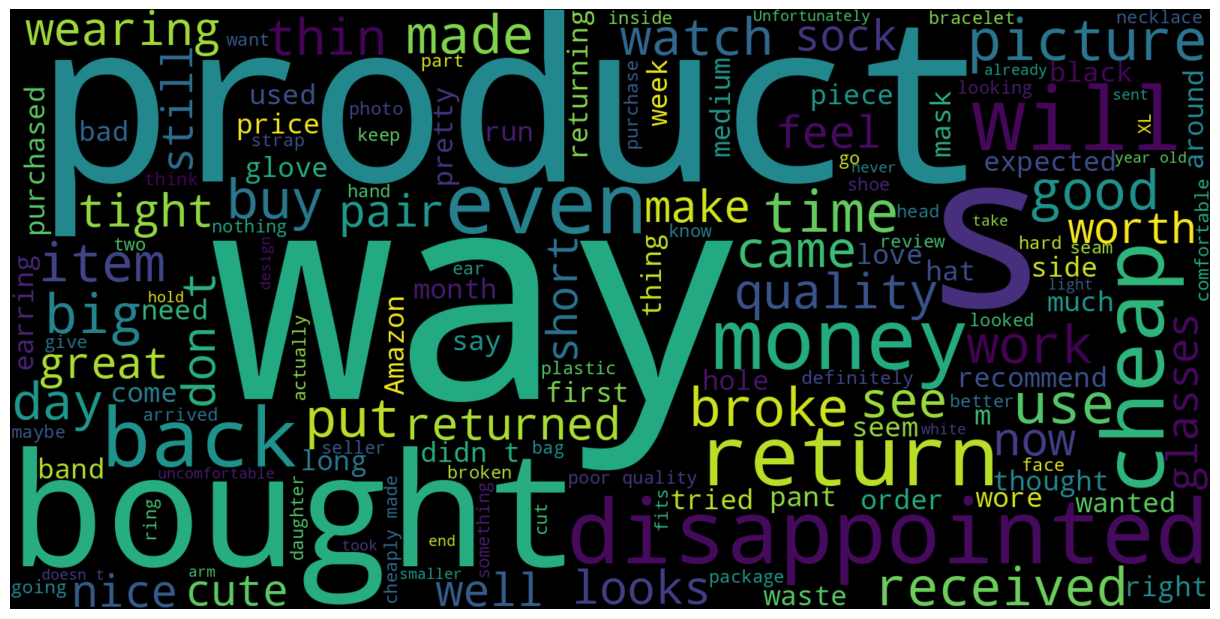

In [ ]:
# ==============================================================================
# VISUALIZATION AND ANALYSIS CELL
# All data is sourced directly from the DuckDB database.
# ==============================================================================

import pandas as pd
import plotly.express as px
from scipy import stats
# Libraries needed for the new Word Cloud visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# This code assumes your DuckDB connection 'con' is active from the previous cell.

# --- 1. Top 10 Products by Review Count ---
print("--- 1. Visualizing Top 10 Most Reviewed Products ---")
top_10_query = """
    SELECT
        product_title,
        COUNT(*) as review_count
    FROM reviews
    GROUP BY product_title
    ORDER BY review_count DESC
    LIMIT 10;
"""
top_10_df = con.sql(top_10_query).df()
fig_top10 = px.bar(top_10_df,
                   x='review_count',
                   y='product_title',
                   orientation='h',
                   title='Top 10 Products by Number of 1 & 2-Star Reviews',
                   labels={'review_count': 'Number of Reviews', 'product_title': 'Product Title'},
                   template='plotly_dark',
                   text='review_count')
fig_top10.update_layout(yaxis={'categoryorder':'total ascending'})
fig_top10.show()


# --- 2. Distribution of Ratings ---
print("\n--- 2. Visualizing Distribution of Ratings ---")
ratings_query = "SELECT rating FROM reviews WHERE rating IS NOT NULL;"
ratings_df = con.sql(ratings_query).df()
fig_rating = px.histogram(ratings_df, x="rating", title="Distribution of Ratings",
                          template="plotly_dark", text_auto=True)
fig_rating.update_layout(bargap=0.2)
fig_rating.show()


# --- 3. Distribution of Prices (< $200) ---
print("\n--- 3. Visualizing Distribution of Prices (< $200) ---")
price_query = "SELECT price FROM reviews WHERE price < 200 AND price IS NOT NULL;"
prices_df = con.sql(price_query).df()
fig_price = px.histogram(prices_df, x="price", title="Distribution of Prices (< $200)",
                         template="plotly_dark", nbins=50)
fig_price.show()


# --- 4. T-test for Price Difference Between 1 & 2-Star Ratings ---
print("\n--- 4. Statistical Test: Price Difference for 1 vs 2-Star Ratings ---")
ttest_query = "SELECT rating, price FROM reviews WHERE rating IN (1, 2) AND price IS NOT NULL;"
ttest_df = con.sql(ttest_query).df()
prices_r1 = ttest_df[ttest_df['rating'] == 1]['price']
prices_r2 = ttest_df[ttest_df['rating'] == 2]['price']
t_stat, p_value = stats.ttest_ind(prices_r1, prices_r2, equal_var=False, nan_policy='omit')
print(f"Independent Samples T-test Results:")
print(f"  T-statistic: {t_stat:.4f}")
print(f"  P-value: {p_value:.4f}")
alpha = 0.05
if p_value < alpha:
    print("\nInterpretation: The difference in the mean price between 1-star and 2-star rated products is statistically significant (p < 0.05).")
else:
    print("\nInterpretation: The difference in the mean price between 1-star and 2-star rated products is not statistically significant (p >= 0.05).")


# --- 5. Complaint Volume Over Time ---
print("\n--- 5. Visualizing Complaint Volume Over Time ---")
monthly_query = """
    SELECT
        DATE_TRUNC('month', to_timestamp(timestamp / 1000)) AS month,
        COUNT(*) AS complaint_count
    FROM reviews
    GROUP BY month
    ORDER BY month;
"""
monthly_counts_df = con.sql(monthly_query).df()
if not monthly_counts_df.empty:
    fig_monthly_volume = px.line(monthly_counts_df, x="month", y="complaint_count",
                                 title="Monthly Complaint Volume (1 and 2-star Reviews)",
                                 template="plotly_dark", markers=True,
                                 labels={"month": "Month", "complaint_count": "Complaint Count"})
    fig_monthly_volume.show()
else:
    print("No data available to plot monthly complaint volume.")


# --- 6. Word Cloud of Review Text ---
print("\n--- 6. Generating Word Cloud from Review Text ---")
# Query to get all review texts from DuckDB
text_query = "SELECT text FROM reviews WHERE text IS NOT NULL;"
text_df = con.sql(text_query).df()

# Join all the review texts into a single large string
all_text = " ".join(review for review in text_df['text'])

# Define a set of stopwords: start with the default and add custom words
# common to fashion reviews to get more meaningful results.
stopwords = set(STOPWORDS)
stopwords.update(["br", "size", "wear", "fit", "color", "look", "like", "fabric",
                  "material", "shirt", "dress", "top", "ordered", "got", "one",
                  "would", "really", "small", "large", "little"])

# Create the WordCloud object with desired styling
wordcloud = WordCloud(width=1600, height=800,
                      background_color='black',
                      stopwords=stopwords,
                      max_words=150,
                      colormap='viridis',
                      min_font_size=10).generate(all_text)

# Display the generated image using matplotlib
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

#**Supervised Finetuning Label Generation with Gemini 2.5 Google GenAI API**

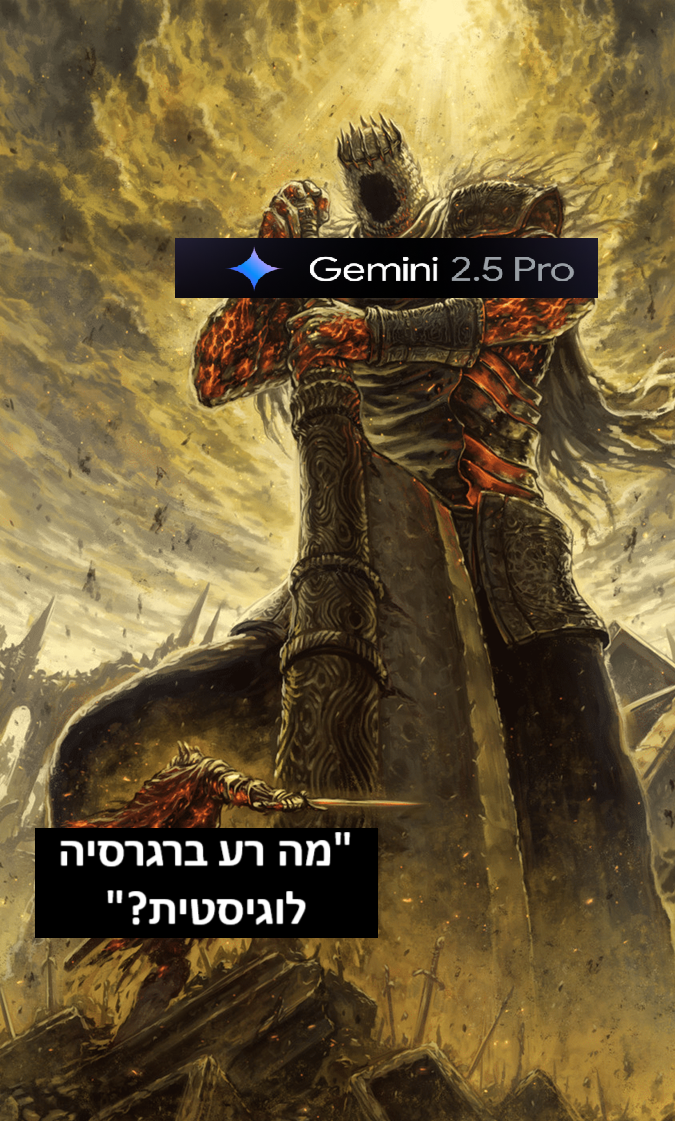

In [ ]:
#Transition Meme to SFT Generation
from IPython.display import Image
display(Image('/content/drive/MyDrive/גמיני.png', width=400, height=500))

In [ ]:
# ==============================================================================
# Final Cell: Simplified Synchronous Labeling
# This cell should be run AFTER your "Cell 1" has successfully loaded df_complaints.
# ==============================================================================

# --- 1. Imports and Setup ---
import os
import json
import hashlib
import logging
import re
import time
from typing import List, Literal, Dict
from enum import Enum

# Third-party libraries (already installed in Cell 1)
import polars as pl
from google import genai
from pydantic import BaseModel, ValidationError
from tqdm.auto import tqdm
from IPython.display import display, Markdown

# --- 2. Configuration and Constants ---
OUTPUT_FOLDER = "complaint_labeling_output"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
print(f"--- 1. Output folder '{OUTPUT_FOLDER}' ensured. ---")

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s', force=True)
logger = logging.getLogger(__name__)
print("--- 2. Detailed logger configured. ---")

# --- Simplified Configuration for a Stable, Single-Model Run ---
MODEL_ID = "gemini-2.5-pro"
MAX_RECORDS_TO_LABEL = 500
BATCH_SIZE = 50
DELAY_BETWEEN_CALLS = 12 # 12 seconds for gemini-2.5-pro's 5 RPM limit

# --- 3. Data Preparation ---
def create_hash(row_struct: Dict) -> str:
    unique_string = f"{row_struct.get('text', '')}-{row_struct.get('product_title', '')}"
    return hashlib.sha256(unique_string.encode('utf-8')).hexdigest()

df_complaints_hashed = df_complaints.with_columns(
    pl.struct(["text", "product_title"]).map_elements(create_hash, return_dtype=pl.String).alias("content_hash")
)
print("--- 3. 'content_hash' column created for checkpointing. ---")


# --- 4. Define Core Logic (Schema, Prompt, and Cleaning) ---
print("--- 4. Defining Core Logic... ---")

class ComplaintCategory(str, Enum):
    DAMAGED_OR_DEFECTIVE = "Damaged or Defective"
    ITEM_NOT_AS_DESCRIBED = "Item Not as Described"
    INCORRECT_SIZE_FIT = "Incorrect Size / Fit"
    WRONG_OR_INCOMPLETE_ORDER = "Wrong or Incomplete Order"
    NA = "N/A"

class ResolutionRecommendation(str, Enum):
    FULL_REFUND = "Full Refund"
    REPLACEMENT = "Replacement"
    RESEND = "Resend"
    NA = "N/A"

class GeminiOutputSchema(BaseModel):
    content_hash: str
    info_complete: Literal[0, 1]
    is_actionable: Literal[0, 1]
    complaint_category: ComplaintCategory
    resolution_recommendation: ResolutionRecommendation

AMAZON_POLICY_PRINCIPLES = """
- **Goal:** Resolve valid issues quickly.
- **Valid Reasons:** `Damaged or Defective`, `Item Not as Described`, `Wrong or Incomplete Order`, `Incorrect Size / Fit`.
- **Resolutions:**
  - Damaged/Defective OR Incorrect Size/Fit -> **Replacement**.
  - Wrong or Incomplete Order -> **Resend**.
  - Item Not as Described -> **Full Refund**.
- **Flexibility Principle:** If a customer is highly dissatisfied or explicitly requests a refund, prioritize **Full Refund**.
"""

TEACHER_PROMPT_TEMPLATE = """
As an expert Amazon AI agent, analyze the batch of complaints based on the provided policy. For each complaint, generate a structured JSON object.
**GUIDING POLICY & PRINCIPLES:**
{amazon_policy}
**BATCH OF CUSTOMER COMPLAINTS:**
{complaints_batch_json}
**INSTRUCTIONS:**
- Your response MUST be a single, valid JSON array, containing one JSON object for each complaint.
- Do not include any text, explanations, or markdown formatting (like ```json) before or after the JSON array.
- Each JSON object MUST follow this exact schema:
{{
    "content_hash": "string",
    "info_complete": integer (0 or 1),
    "is_actionable": integer (0 or 1),
    "complaint_category": "string (e.g., 'Damaged or Defective', 'N/A')",
    "resolution_recommendation": "string (e.g., 'Replacement', 'N/A')"
}}
"""

def clean_and_parse_json(raw_text: str) -> list:
    cleaned_text = re.sub(r'```json\s*|\s*```', '', raw_text.strip())
    return json.loads(cleaned_text)

print("✅ Core logic components defined.")

# --- 5. Synchronous Generation Loop ---
display(Markdown(f"### --- 5. Starting SYNCHRONOUS labeling process for {MODEL_ID}... ---"))

# *** THE FIX IS HERE: Use genai.Client() as per the SDK documentation ***
# Your API key is already configured from Cell 1.
client = genai.Client()
all_results = []
records_to_process = df_complaints_hashed.head(MAX_RECORDS_TO_LABEL)
batches = [records_to_process.slice(i, BATCH_SIZE) for i in range(0, len(records_to_process), BATCH_SIZE)]

for batch in tqdm(batches, desc="Processing Batches Synchronously"):
    batch_hashes = batch['content_hash'].to_list()
    logger.info(f"Processing batch for hashes starting with: {batch_hashes[:10]}...")

    try:
        complaints_for_prompt = batch.select("content_hash", "text", "product_title").to_dicts()

        prompt = TEACHER_PROMPT_TEMPLATE.format(
            amazon_policy=AMAZON_POLICY_PRINCIPLES,
            complaints_batch_json=json.dumps(complaints_for_prompt, indent=2)
        )

        # *** THE FIX IS HERE: Call the API using the client.models object ***
        response = client.models.generate_content(
            model=MODEL_ID,
            contents=prompt
        )

        cleaned_list = clean_and_parse_json(response.text)
        validated_data = [GeminiOutputSchema(**item) for item in cleaned_list]
        results_list = [item.model_dump() for item in validated_data]

        for res in results_list:
            res['quality_status'] = "PROCESSED"
        all_results.extend(results_list)
        logger.info(f"✅ Successfully processed and validated batch {batch_hashes[:10]}...")

    except Exception as e:
        logger.error(f"❌ Batch FAILED on hashes starting with {batch_hashes[:10]}. FULL ERROR:", exc_info=True)
        error_results = [
            {"content_hash": h, "quality_status": "API_ERROR", "error_message": f"{type(e).__name__}: {str(e)[:500]}"}
            for h in batch_hashes
        ]
        all_results.extend(error_results)

    finally:
        logger.info(f"Waiting for {DELAY_BETWEEN_CALLS} seconds before next API call...")
        time.sleep(DELAY_BETWEEN_CALLS)

display(Markdown("### ✅ Synchronous labeling finished."))

# --- 6. Final Consolidation and Saving ---
print("\n--- 6. Consolidating Results and Finalizing Dataset... ---")
if not all_results:
    print("No results were generated. Exiting.")
else:
    df_results = pl.from_records(all_results)
    df_results = df_results.with_columns(pl.lit(MODEL_ID).alias("model_id"))

    df_final = df_complaints_hashed.join(df_results, on="content_hash", how="left")

    df_success = df_final.filter(pl.col("quality_status") == "PROCESSED")
    df_errors = df_final.filter(pl.col("quality_status") != "PROCESSED")

    SUCCESS_PATH = os.path.join(OUTPUT_FOLDER, f"labeled_complaints_{MAX_RECORDS_TO_LABEL}.csv")
    ERROR_PATH = os.path.join(OUTPUT_FOLDER, f"error_log_{MAX_RECORDS_TO_LABEL}.csv")

    df_success.write_csv(SUCCESS_PATH)
    print(f"✅ Saved {len(df_success)} successfully labeled records to '{SUCCESS_PATH}'.")

    if len(df_errors) > 0:
        df_errors.write_csv(ERROR_PATH)
        print(f"✅ Saved {len(df_errors)} error records for review to '{ERROR_PATH}'.")
        print("\nError Cases Sample:")
        display(df_errors.head().to_pandas())
    else:
        print("✅ No error cases were recorded.")

    print("\n--- Data Generation Phase Complete! ---")

--- 1. Output folder 'complaint_labeling_output' ensured. ---
--- 2. Detailed logger configured. ---
--- 3. 'content_hash' column created for checkpointing. ---
--- 4. Defining Core Logic... ---
✅ Core logic components defined.


### --- 5. Starting SYNCHRONOUS labeling process for gemini-2.5-pro... ---

Processing Batches Synchronously:   0%|          | 0/10 [00:00<?, ?it/s]

2025-09-09 05:10:28,168 - INFO - Processing batch for hashes starting with: ['93878ac035da665ce163e0b0bc0b6653356cd39fc201685b00afab0fe9f47e3f', 'b237dd889138a2aa562f213773ce9ea5b7dd537d77f22c63887fd9f995b6cd94', '324dfb65420f74102d99da67f6706693023fdedb1a36cf39e35bfafb15a50e19', 'e56bc8c951856128bcf5f4a121059597c2948d08f5b36af7dcc635f7a093a63e', 'ae21ab0cda63cb521a107af8015a4ffd0e4c31cdda917085a750d695ccc0b29b', '7e327265edd283a8653951299123e83fbd6d99ad3e7dde726960faf96ffe67ab', 'a27e1bfb7fd38b213a8107ae40a593524b7ae39c75c3e12b71f4dd892a40d17a', '2850178456ae601acbdf03a786440a14f6775e8aec56c33cfc9fbeadc894179f', 'd222ee2887e530604281db3171dc8f05e76b919bf6ad7dcf2a99e611c94c4ff4', 'f1a75e1480561006c79803a575fb2a5207c6ff49931ea20d99697a13ac8ce997']...
2025-09-09 05:10:28,179 - INFO - AFC is enabled with max remote calls: 10.
2025-09-09 05:12:45,728 - INFO - HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-pro:generateContent "HTTP/1.1 200 OK"
2025-09-

### ✅ Synchronous labeling finished.


--- 6. Consolidating Results and Finalizing Dataset... ---
✅ Saved 492 successfully labeled records to 'complaint_labeling_output/labeled_complaints_500.csv'.
✅ No error cases were recorded.

--- Data Generation Phase Complete! ---


In [ ]:
# ==============================================================================
# 🕵️‍♂️ Meme Analysis & Visualization Cell 📊
# Let's see what our AI chef cooked up!
# ==============================================================================
import polars as pl
import plotly.express as px
from IPython.display import display, Markdown

# --- 1. Load the Masterpiece ---
# Define the path to the file we just created
LABELED_FILE_PATH = 'complaint_labeling_output/labeled_complaints_500.csv'
Markdown(f"### 🧐 Let's peek inside the newly created file: `{LABELED_FILE_PATH}`")

try:
    # Load the data into a Polars DataFrame
    df_labeled = pl.read_csv(LABELED_FILE_PATH)

    # --- 2. The Grand Reveal: "Show me the data!" ---
    display(Markdown("Behold! The glorious, structured data, fresh from the AI's brain. The original complaint is now enriched with juicy new columns!"))
    # Display the first few rows in a nice format
    display(df_labeled.head().to_pandas())

    # --- 3. The Main Event: PRETTY GRAPHS! ---
    display(Markdown("--- \n ### 📊 Now, let's visualize the AI's decisions..."))

    # Columns generated by the Gemini model that we want to analyze
    cols_to_plot = [
        'info_complete',
        'is_actionable',
        'complaint_category',
        'resolution_recommendation'
    ]

    for col_name in cols_to_plot:
        # Calculate the distribution (value counts) for the column
        distribution = df_labeled.group_by(col_name).count().sort(by='count', descending=True)

        # Create a title with some flair
        title_text = f"🤖 AI's Verdict: Distribution of '{col_name.replace('_', ' ').title()}'"

        # Create an interactive bar chart with Plotly Express
        fig = px.bar(
            distribution,
            x=col_name,
            y='count',
            color=col_name,
            title=title_text,
            text_auto=True,  # Automatically add labels on top of the bars
            template='plotly_dark' # A cool theme
        )

        # Center the title because we're fancy
        fig.update_layout(title_x=0.5)

        # Show the plot
        fig.show()

    display(Markdown("--- \n ### ✅ Analysis Complete!"))
    display(Markdown("Looks like our AI has some strong opinions! The charts above show exactly how it categorized and recommended resolutions for the complaints."))


except FileNotFoundError:
    print(f"❌ OH NO! The file '{LABELED_FILE_PATH}' was not found.")
    print("Please make sure the first script ran successfully and created the output file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Behold! The glorious, structured data, fresh from the AI's brain. The original complaint is now enriched with juicy new columns!

,original_index,text,product_title,price,rating,content_hash,info_complete,is_actionable,complaint_category,resolution_recommendation,quality_status,model_id
0,10451,"These have fallen apart in less than 2 months,...",NELEUS Women's 3 Pack Compression Base Layer D...,21.96,2.0,93878ac035da665ce163e0b0bc0b6653356cd39fc20168...,1,1,Damaged or Defective,Replacement,PROCESSED,gemini-2.5-pro
1,19384,So flat like an ass,Jeanewpole1 Womens Down Puffer Short Jacket Qu...,54.99,1.0,b237dd889138a2aa562f213773ce9ea5b7dd537d77f22c...,1,1,Item Not as Described,Full Refund,PROCESSED,gemini-2.5-pro
2,35367,"The description says the dress has ""some stret...",LILBETTER Women V-Neck Polka Dot Print Spaghet...,35.99,2.0,324dfb65420f74102d99da67f6706693023fdedb1a36cf...,1,1,Item Not as Described,Full Refund,PROCESSED,gemini-2.5-pro
3,20883,"Way too large, material also stretches out. Or...",U.S. Polo Assn. Womens Jogger Lounge Pants  P...,14.95,2.0,e56bc8c951856128bcf5f4a121059597c2948d08f5b36a...,1,1,Incorrect Size / Fit,Replacement,PROCESSED,gemini-2.5-pro
4,954,If you're looking for harem pants these will b...,WearAll Womens Plus Size Cropped Harem Trouser...,17.25,2.0,ae21ab0cda63cb521a107af8015a4ffd0e4c31cdda9170...,1,1,Damaged or Defective,Replacement,PROCESSED,gemini-2.5-pro


--- 
 ### 📊 Now, let's visualize the AI's decisions...

/tmp/ipython-input-1847496169.py:36: DeprecationWarning: `GroupBy.count` is deprecated. It has been renamed to `len`.
  distribution = df_labeled.group_by(col_name).count().sort(by='count', descending=True)
2025-09-09 05:34:46,575 - ERROR - Task was destroyed but it is pending!
task: <Task pending name='Task-185' coro=<worker() running at /tmp/ipython-input-506831212.py:181> wait_for=<Future pending cb=[Task.task_wakeup()]>>
2025-09-09 05:34:46,576 - ERROR - Task was destroyed but it is pending!
task: <Task pending name='Task-187' coro=<worker() running at /tmp/ipython-input-506831212.py:181> wait_for=<Future pending cb=[Task.task_wakeup()]>>
2025-09-09 05:34:46,578 - ERROR - Task was destroyed but it is pending!
task: <Task pending name='Task-186' coro=<worker() running at /tmp/ipython-input-506831212.py:181> wait_for=<Future pending cb=[Task.task_wakeup()]>>
2025-09-09 05:34:46,579 - ERROR - Task was destroyed but it is pending!
task: <Task pending name='Task-184' coro=<worker() runn

/tmp/ipython-input-1847496169.py:36: DeprecationWarning:

`GroupBy.count` is deprecated. It has been renamed to `len`.



/tmp/ipython-input-1847496169.py:36: DeprecationWarning:

`GroupBy.count` is deprecated. It has been renamed to `len`.



/tmp/ipython-input-1847496169.py:36: DeprecationWarning:

`GroupBy.count` is deprecated. It has been renamed to `len`.



--- 
 ### ✅ Analysis Complete!

Looks like our AI has some strong opinions! The charts above show exactly how it categorized and recommended resolutions for the complaints.